In [27]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_unique_students_by_year(
    df: pd.DataFrame,
    student_col: str = "student_id",
    part_col: str = "part_id",
    min_year: int = 2014,
    figsize=(12, 6),
):
    """
    Plot number of unique students per academic year based on part_id.

    Assumption:
    part_id format starts with year, for example:
    20141, 20142, 20164, 20222, etc.

    Parameters:
    - df: input dataframe
    - student_col: student ID column name
    - part_col: semester/part column name
    - min_year: minimum year to keep
    """

    data = df.copy()

    required_cols = [student_col, part_col]
    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # Convert part_id safely to numeric first
    data[part_col] = pd.to_numeric(data[part_col], errors="coerce")

    # Remove rows with missing student_id or part_id
    data = data.dropna(subset=[student_col, part_col]).copy()

    # Convert part_id like 20164.0 to "20164"
    data["part_id_clean"] = data[part_col].astype(int).astype(str)

    # Extract year from first 4 digits
    data["year"] = pd.to_numeric(
        data["part_id_clean"].str[:4],
        errors="coerce"
    )

    # Keep only valid years
    data = data.dropna(subset=["year"]).copy()
    data["year"] = data["year"].astype(int)

    # Filter from 2014 and higher
    data = data[data["year"] >= min_year].copy()

    # Count unique students per year
    yearly_students = (
        data.groupby("year")[student_col]
        .nunique()
        .reset_index(name="unique_students")
        .sort_values("year")
    )

    display(yearly_students)

    # Plot
    plt.figure(figsize=figsize)
    plt.plot(
        yearly_students["year"],
        yearly_students["unique_students"],
        marker="o"
    )

    plt.title(f"Unique Students per Year from {min_year}+")
    plt.xlabel("Year")
    plt.ylabel("Number of Unique Students")
    plt.xticks(yearly_students["year"], rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return yearly_students

In [28]:
row_student_df=pd.read_parquet(r"D:\AI\Real projects\Academic_Advisor\data\raw\v_crg_student_course_raw.parquet")

,year,unique_students
0,2014,2149
1,2015,2738
2,2016,3418
3,2017,4238
4,2018,4600
5,2019,5103
6,2020,5891
7,2021,6935
8,2022,7052
9,2023,7358


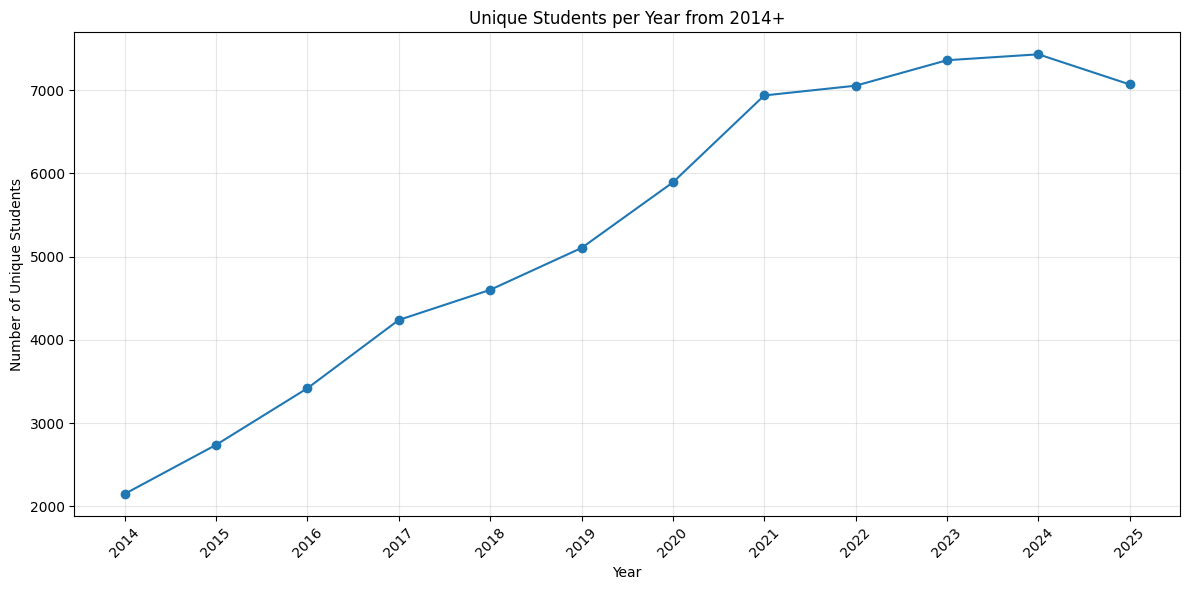

In [29]:
yearly_students = plot_unique_students_by_year(
    df=row_student_df,
    student_col="student_id",
    part_col="part_id",
    min_year=2014
)

,year,unique_students
0,2014,2632
1,2015,3085
2,2016,3582
3,2017,4405
4,2018,4833
5,2019,5289
6,2020,6439
7,2021,8828
8,2022,6555
9,2023,5321


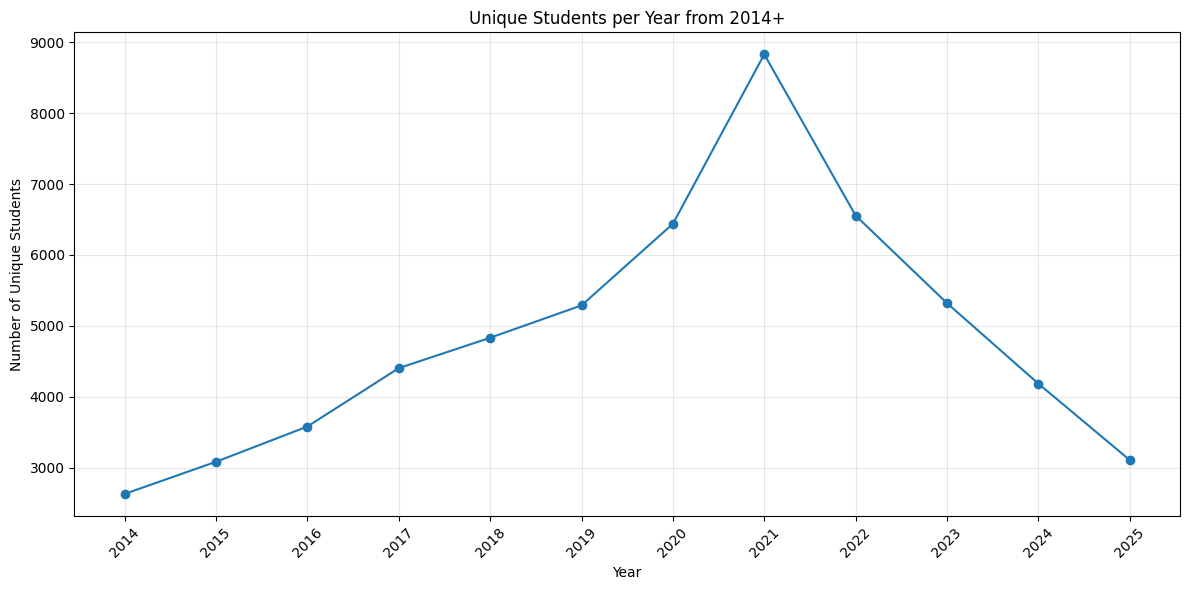

In [30]:
row_status_df=pd.read_parquet(r"D:\AI\Real projects\Academic_Advisor\data\raw\v_add_student_degree_status.parquet")
yearly_students = plot_unique_students_by_year(
    df=row_status_df,
    student_col="student_id",
    part_col="part_id",
    min_year=2014
)

In [31]:
def plot_unique_students_by_year_and_degree(
    df: pd.DataFrame,
    student_col: str = "student_id",
    degree_col: str = "degree_id",
    part_col: str = "part_id",
    min_year: int = 2014,
    top_n_degrees: int | None = None,
    figsize=(14, 7),
):
    """
    Plot number of unique students per year grouped by degree_id.

    Counts:
    - unique student_id
    - grouped by year extracted from part_id
    - grouped by degree_id

    part_id examples:
    - 20141
    - 20164
    - 20222
    """

    data = df.copy()

    required_cols = [student_col, degree_col, part_col]
    missing_cols = [col for col in required_cols if col not in data.columns]

    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # Convert safely
    data[part_col] = pd.to_numeric(data[part_col], errors="coerce")
    data[degree_col] = pd.to_numeric(data[degree_col], errors="coerce")

    # Drop rows missing important keys
    data = data.dropna(subset=[student_col, degree_col, part_col]).copy()

    # Clean part_id and extract year
    data["part_id_clean"] = data[part_col].astype(int).astype(str)
    data["year"] = pd.to_numeric(
        data["part_id_clean"].str[:4],
        errors="coerce"
    )

    data = data.dropna(subset=["year"]).copy()
    data["year"] = data["year"].astype(int)

    # Keep years >= min_year
    data = data[data["year"] >= min_year].copy()

    # Count unique students per year and degree
    yearly_degree_students = (
        data.groupby(["year", degree_col])[student_col]
        .nunique()
        .reset_index(name="unique_students")
        .sort_values(["year", degree_col])
    )

    # Optional: keep only top N degrees by total unique student count
    if top_n_degrees is not None:
        top_degrees = (
            yearly_degree_students
            .groupby(degree_col)["unique_students"]
            .sum()
            .sort_values(ascending=False)
            .head(top_n_degrees)
            .index
        )

        yearly_degree_students = yearly_degree_students[
            yearly_degree_students[degree_col].isin(top_degrees)
        ].copy()

    display(yearly_degree_students)

    # Pivot for plotting
    pivot_df = yearly_degree_students.pivot(
        index="year",
        columns=degree_col,
        values="unique_students"
    ).fillna(0)

    # Plot
    plt.figure(figsize=figsize)

    for degree_id in pivot_df.columns:
        plt.plot(
            pivot_df.index,
            pivot_df[degree_id],
            marker="o",
            label=f"Degree {degree_id}"
        )

    plt.title(f"Unique Students by Year and Degree ID from {min_year}+")
    plt.xlabel("Year")
    plt.ylabel("Number of Unique Students")
    plt.xticks(pivot_df.index, rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend(title="degree_id", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return yearly_degree_students, pivot_df

,year,degree_id,unique_students
0,2014,1.111,499
1,2014,2.111,477
2,2014,3.111,61
3,2014,4.111,4
4,2014,5.111,7
...,...,...,...
191,2025,16.111,4
192,2025,19.111,1
193,2025,20.111,3
194,2025,22.111,57


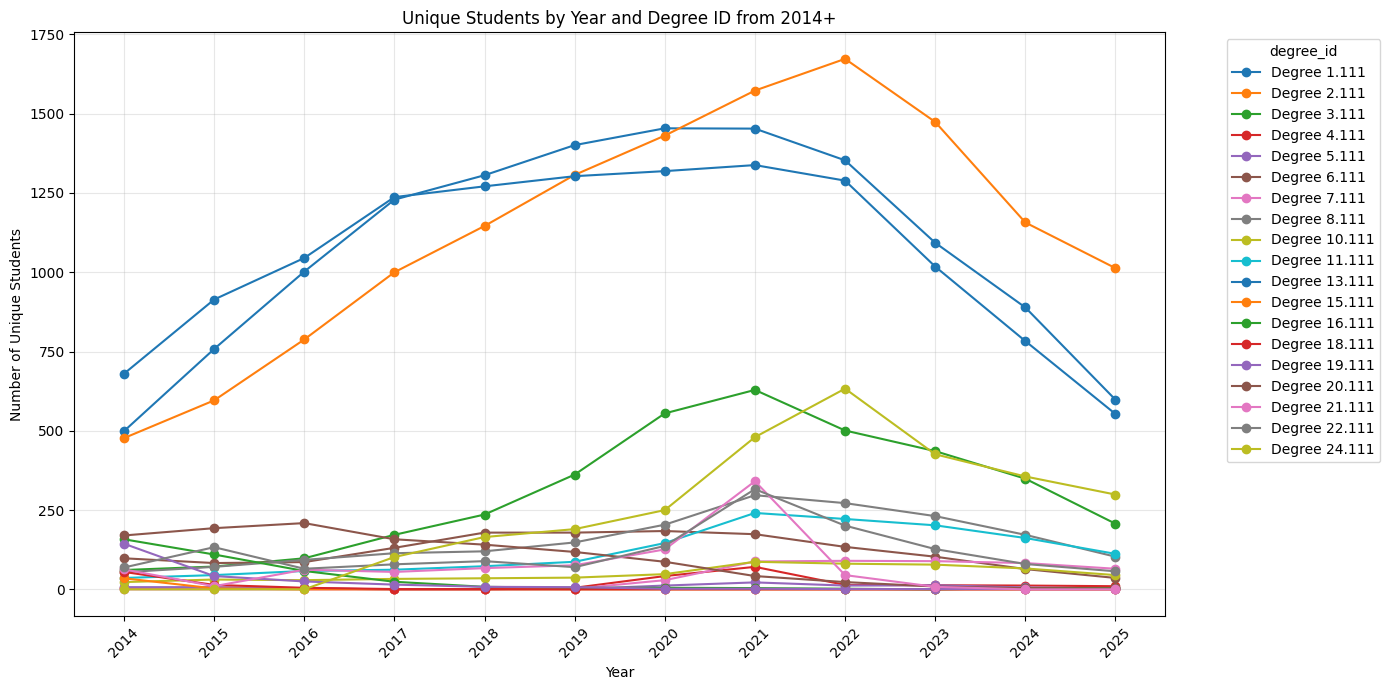

In [32]:
yearly_degree_students, pivot_df = plot_unique_students_by_year_and_degree(
    df=row_status_df,
    student_col="student_id",
    degree_col="degree_id",
    part_col="part_id",
    min_year=2014
)

,year,degree_id,unique_students
0,2014,1.111,460
1,2014,2.111,418
2,2014,3.111,58
3,2014,4.111,4
4,2014,5.111,7
...,...,...,...
286,2025,59.111,64
287,2025,60.111,50
288,2025,61.111,49
289,2025,64.111,54


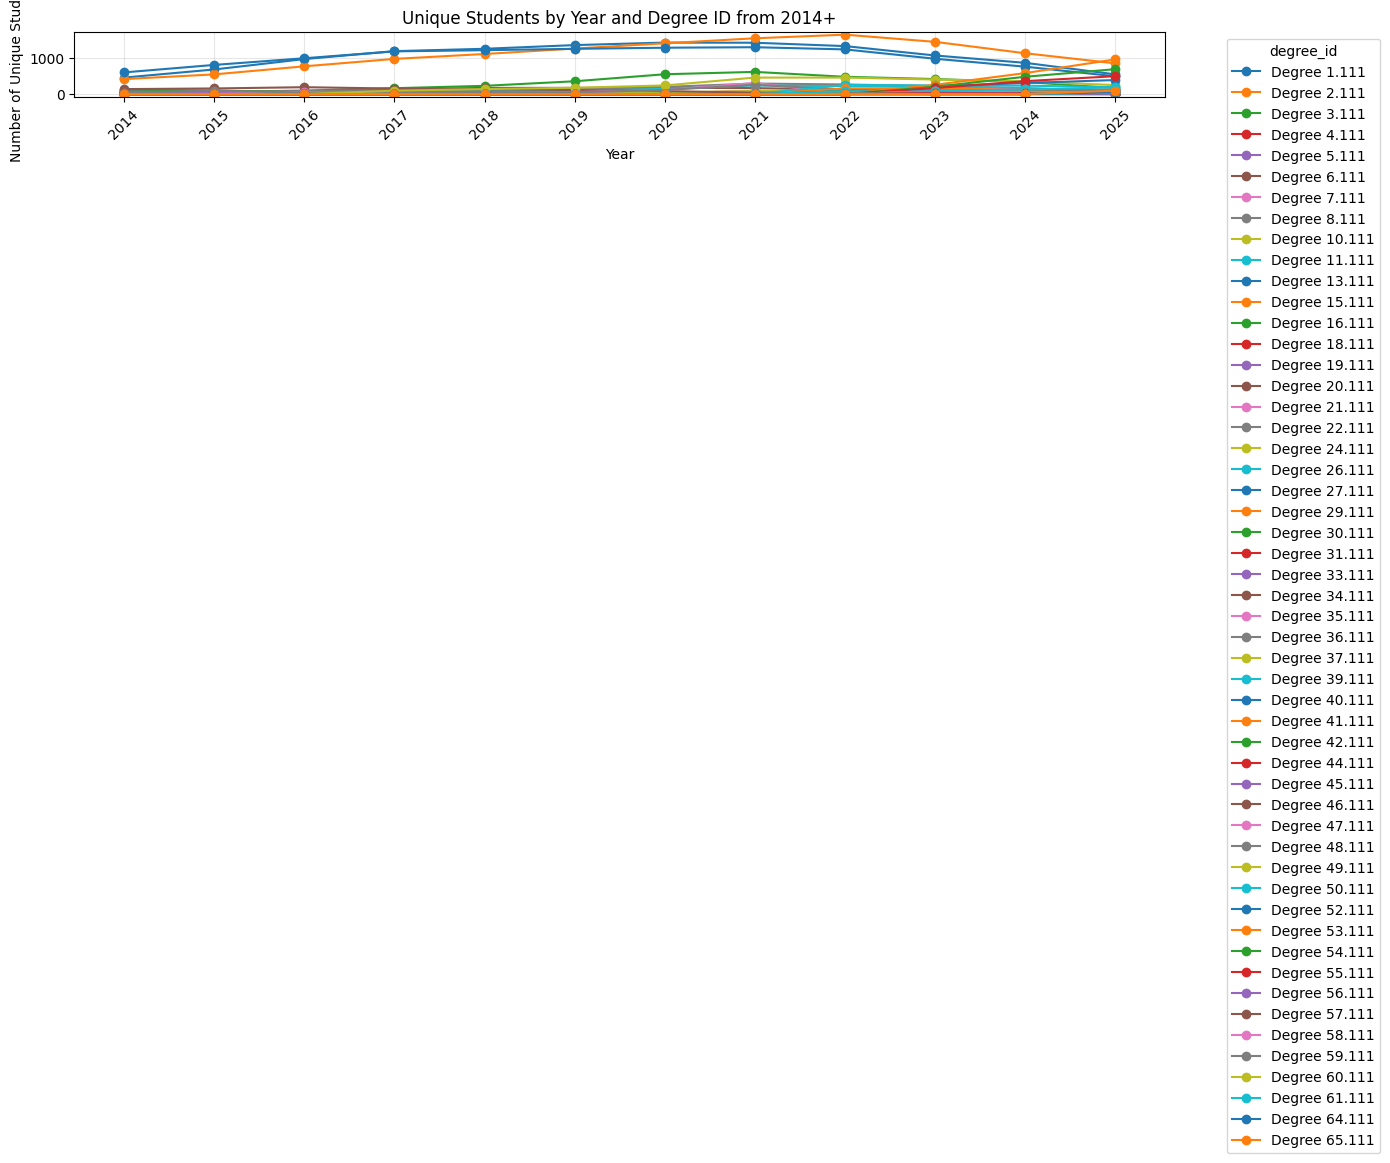

In [33]:
yearly_degree_students, pivot_df = plot_unique_students_by_year_and_degree(
    df=row_student_df,
    student_col="student_id",
    degree_col="degree_id",
    part_col="part_id",
    min_year=2014
)

In [34]:
import pandas as pd
import matplotlib.pyplot as plt


def prepare_unique_students_by_year_degree(
    df: pd.DataFrame,
    student_col: str = "student_id",
    degree_col: str = "degree_id",
    part_col: str = "part_id",
    min_year: int = 2014,
):
    data = df.copy()

    required_cols = [student_col, degree_col, part_col]
    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    data[part_col] = pd.to_numeric(data[part_col], errors="coerce")
    data[degree_col] = pd.to_numeric(data[degree_col], errors="coerce")

    data = data.dropna(subset=[student_col, degree_col, part_col]).copy()

    # Extract year from part_id, example: 20164.0 -> 2016
    data["part_id_clean"] = data[part_col].astype(int).astype(str)
    data["year"] = pd.to_numeric(data["part_id_clean"].str[:4], errors="coerce")

    data = data.dropna(subset=["year"]).copy()
    data["year"] = data["year"].astype(int)

    data = data[data["year"] >= min_year].copy()

    # For display only: Degree 1.111 becomes 1 if your IDs have .111 artifact
    data["degree_id_display"] = data[degree_col].astype(int).astype(str)

    yearly_degree_students = (
        data.groupby(["year", "degree_id_display"])[student_col]
        .nunique()
        .reset_index(name="unique_students")
        .sort_values(["year", "degree_id_display"])
    )

    pivot_df = yearly_degree_students.pivot(
        index="year",
        columns="degree_id_display",
        values="unique_students"
    ).fillna(0)

    return yearly_degree_students, pivot_df

In [35]:
yearly_degree_students, pivot_df = prepare_unique_students_by_year_degree(
    df=row_student_df,
    student_col="student_id",
    degree_col="degree_id",
    part_col="part_id",
    min_year=2014
)

In [36]:
yearly_degree_students, pivot_df = prepare_unique_students_by_year_degree(
    df=row_status_df,
    student_col="student_id",
    degree_col="degree_id",
    part_col="part_id",
    min_year=2014
)

In [37]:
def plot_top_degrees_line(
    df: pd.DataFrame,
    student_col: str = "student_id",
    degree_col: str = "degree_id",
    part_col: str = "part_id",
    min_year: int = 2014,
    top_n: int = 10,
    figsize=(14, 7),
):
    yearly_degree_students, pivot_df = prepare_unique_students_by_year_degree(
        df=df,
        student_col=student_col,
        degree_col=degree_col,
        part_col=part_col,
        min_year=min_year,
    )

    top_degrees = (
        pivot_df.sum(axis=0)
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    plot_df = pivot_df[top_degrees]

    plt.figure(figsize=figsize)

    for degree_id in plot_df.columns:
        plt.plot(
            plot_df.index,
            plot_df[degree_id],
            marker="o",
            linewidth=2,
            label=f"Degree {degree_id}"
        )

    plt.title(f"Top {top_n} Degrees by Unique Students per Year")
    plt.xlabel("Year")
    plt.ylabel("Unique Students")
    plt.xticks(plot_df.index, rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend(
        title="degree_id",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.tight_layout()
    plt.show()

    return yearly_degree_students, plot_df

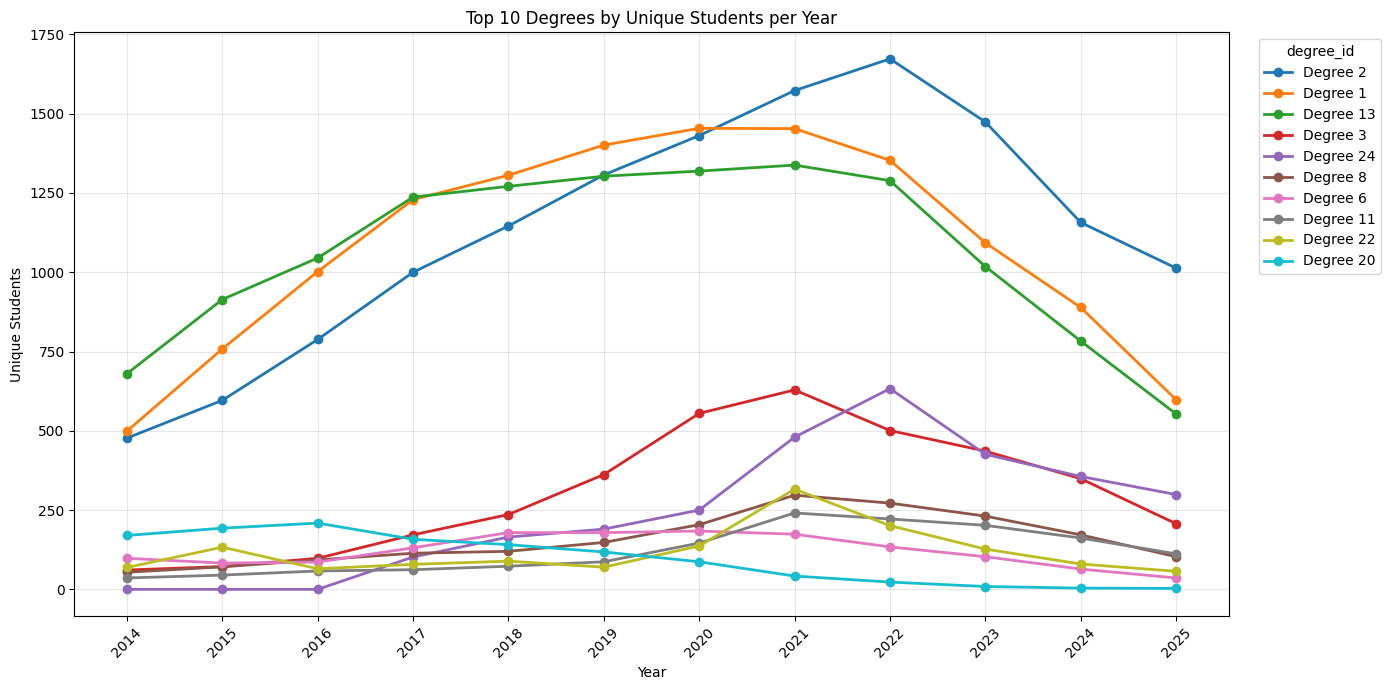

In [38]:
yearly_degree_students, top_plot_df = plot_top_degrees_line(
    df=row_status_df,
    student_col="student_id",
    degree_col="degree_id",
    part_col="part_id",
    min_year=2014,
    top_n=10
)

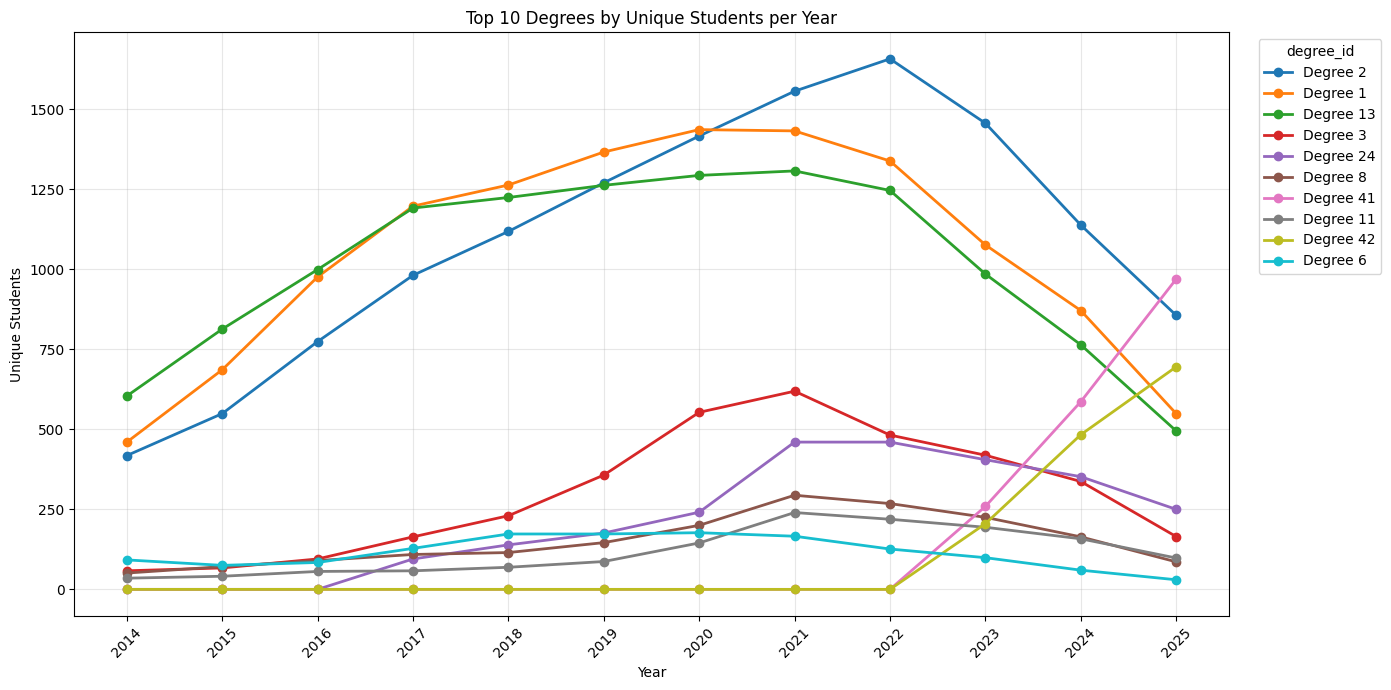

In [39]:
yearly_degree_students, top_plot_df = plot_top_degrees_line(
    df=row_student_df,
    student_col="student_id",
    degree_col="degree_id",
    part_col="part_id",
    min_year=2014,
    top_n=10
)

In [40]:
def plot_degrees_heatmap(
    df: pd.DataFrame,
    student_col: str = "student_id",
    degree_col: str = "degree_id",
    part_col: str = "part_id",
    min_year: int = 2014,
    min_total_students: int = 0,
    figsize=(14, 12),
):
    yearly_degree_students, pivot_df = prepare_unique_students_by_year_degree(
        df=df,
        student_col=student_col,
        degree_col=degree_col,
        part_col=part_col,
        min_year=min_year,
    )

    # Remove very small degrees if needed
    if min_total_students > 0:
        kept_degrees = pivot_df.columns[pivot_df.sum(axis=0) >= min_total_students]
        pivot_df = pivot_df[kept_degrees].copy()

    # Sort degrees by total size
    pivot_df = pivot_df[pivot_df.sum(axis=0).sort_values(ascending=False).index]

    heatmap_data = pivot_df.T

    plt.figure(figsize=figsize)
    plt.imshow(heatmap_data, aspect="auto")

    plt.title("Unique Students by Year and Degree ID")
    plt.xlabel("Year")
    plt.ylabel("Degree ID")

    plt.xticks(
        ticks=range(len(heatmap_data.columns)),
        labels=heatmap_data.columns,
        rotation=45
    )

    plt.yticks(
        ticks=range(len(heatmap_data.index)),
        labels=heatmap_data.index
    )

    plt.colorbar(label="Unique Students")
    plt.tight_layout()
    plt.show()

    return yearly_degree_students, pivot_df

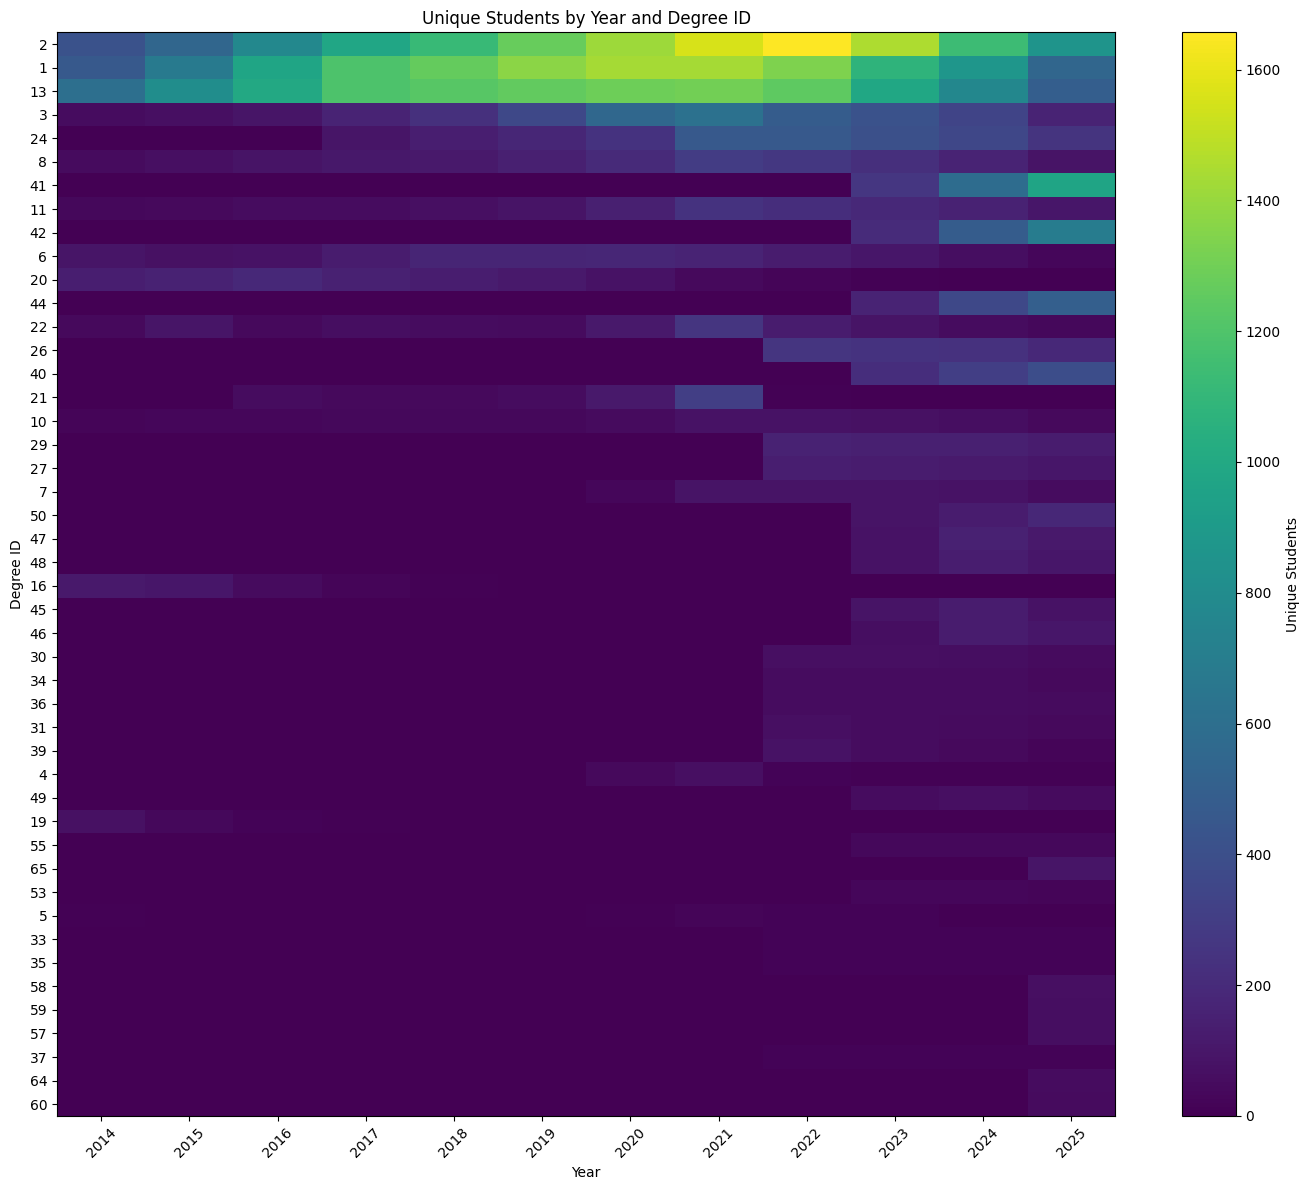

In [41]:
yearly_degree_students, heatmap_df = plot_degrees_heatmap(
    df=row_student_df,
    student_col="student_id",
    degree_col="degree_id",
    part_col="part_id",
    min_year=2014,
    min_total_students=50
)

In [42]:
import pandas as pd
import matplotlib.pyplot as plt


def extract_year_from_part_id(df, part_col="part_id", min_year=2014):
    data = df.copy()

    data[part_col] = pd.to_numeric(data[part_col], errors="coerce")
    data = data.dropna(subset=[part_col]).copy()

    data["part_id_clean"] = data[part_col].astype(int).astype(str)
    data["year"] = pd.to_numeric(data["part_id_clean"].str[:4], errors="coerce")

    data = data.dropna(subset=["year"]).copy()
    data["year"] = data["year"].astype(int)

    data = data[data["year"] >= min_year].copy()

    return data


def audit_status_course_student_overlap(
    status_df: pd.DataFrame,
    course_df: pd.DataFrame,
    student_col: str = "student_id",
    part_col: str = "part_id",
    degree_col: str = "degree_id",
    min_year: int = 2014,
):
    status = extract_year_from_part_id(status_df, part_col=part_col, min_year=min_year)
    course = extract_year_from_part_id(course_df, part_col=part_col, min_year=min_year)

    # Keep required columns if available
    status_students = set(status[student_col].dropna().unique())
    course_students = set(course[student_col].dropna().unique())

    both_students = status_students.intersection(course_students)
    only_status_students = status_students - course_students
    only_course_students = course_students - status_students

    print("========== STUDENT LEVEL OVERLAP ==========")
    print(f"Status unique students: {len(status_students):,}")
    print(f"Course unique students: {len(course_students):,}")
    print(f"Students in both: {len(both_students):,}")
    print(f"Only in status: {len(only_status_students):,}")
    print(f"Only in course: {len(only_course_students):,}")
    print(f"Course extra over status: {len(course_students) - len(status_students):,}")

    student_overlap_summary = pd.DataFrame({
        "group": ["status_unique", "course_unique", "both", "only_status", "only_course"],
        "count": [
            len(status_students),
            len(course_students),
            len(both_students),
            len(only_status_students),
            len(only_course_students),
        ]
    })

    display(student_overlap_summary)

    # Semester-level overlap
    status_semester_keys = (
        status[[student_col, part_col]]
        .dropna()
        .drop_duplicates()
        .copy()
    )

    course_semester_keys = (
        course[[student_col, part_col]]
        .dropna()
        .drop_duplicates()
        .copy()
    )

    semester_overlap = status_semester_keys.merge(
        course_semester_keys,
        on=[student_col, part_col],
        how="outer",
        indicator=True
    )

    print("\n========== STUDENT + PART LEVEL OVERLAP ==========")
    display(semester_overlap["_merge"].value_counts().reset_index())

    # Degree-level overlap if degree_id exists in both
    degree_overlap = None

    if degree_col in status.columns and degree_col in course.columns:
        status_degree_keys = (
            status[[student_col, part_col, degree_col]]
            .dropna()
            .drop_duplicates()
            .copy()
        )

        course_degree_keys = (
            course[[student_col, part_col, degree_col]]
            .dropna()
            .drop_duplicates()
            .copy()
        )

        degree_overlap = status_degree_keys.merge(
            course_degree_keys,
            on=[student_col, part_col, degree_col],
            how="outer",
            indicator=True
        )

        print("\n========== STUDENT + PART + DEGREE LEVEL OVERLAP ==========")
        display(degree_overlap["_merge"].value_counts().reset_index())

    # Plot student-level overlap
    plt.figure(figsize=(10, 5))
    plt.bar(
        student_overlap_summary["group"],
        student_overlap_summary["count"]
    )
    plt.title(f"Student Overlap Between Status and Course Tables from {min_year}+")
    plt.xlabel("Group")
    plt.ylabel("Unique Students")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "student_overlap_summary": student_overlap_summary,
        "semester_overlap": semester_overlap,
        "degree_overlap": degree_overlap,
        "only_status_students": only_status_students,
        "only_course_students": only_course_students,
        "both_students": both_students,
    }

========== STUDENT LEVEL OVERLAP ==========
Status unique students: 14,127
Course unique students: 15,992
Students in both: 11,154
Only in status: 2,973
Only in course: 4,838
Course extra over status: 1,865


,group,count
0,status_unique,14127
1,course_unique,15992
2,both,11154
3,only_status,2973
4,only_course,4838



========== STUDENT + PART LEVEL OVERLAP ==========


,_merge,count
0,both,134364
1,right_only,20588
2,left_only,8798



========== STUDENT + PART + DEGREE LEVEL OVERLAP ==========


,_merge,count
0,both,134358
1,right_only,20589
2,left_only,6678


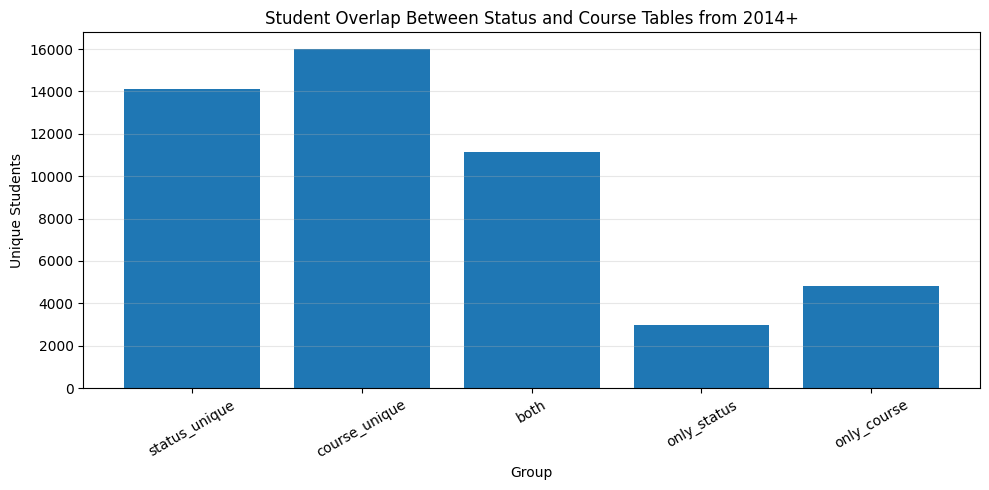

In [43]:
overlap_result = audit_status_course_student_overlap(
    status_df=row_status_df,
    course_df=row_student_df,
    student_col="student_id",
    part_col="part_id",
    degree_col="degree_id",
    min_year=2014
)

In [44]:
import pandas as pd
from pathlib import Path


def prepare_student_overlap_audit(
    status_df: pd.DataFrame,
    course_df: pd.DataFrame,
    student_col: str = "student_id",
    part_col: str = "part_id",
    degree_col: str = "degree_id",
    min_year: int = 2014,
    output_dir: str | Path | None = None,
):
    status = status_df.copy()
    course = course_df.copy()

    # Basic numeric safety
    for df in [status, course]:
        df[student_col] = pd.to_numeric(df[student_col], errors="coerce")
        df[part_col] = pd.to_numeric(df[part_col], errors="coerce")
        if degree_col in df.columns:
            df[degree_col] = pd.to_numeric(df[degree_col], errors="coerce")

    status = status.dropna(subset=[student_col, part_col]).copy()
    course = course.dropna(subset=[student_col, part_col]).copy()

    # Extract year
    status["year"] = status[part_col].astype(int).astype(str).str[:4].astype(int)
    course["year"] = course[part_col].astype(int).astype(str).str[:4].astype(int)

    status = status[status["year"] >= min_year].copy()
    course = course[course["year"] >= min_year].copy()

    # Use rounded string key to avoid float display issues
    status["student_key"] = status[student_col].round(3).astype(str)
    course["student_key"] = course[student_col].round(3).astype(str)

    status_students = (
        status[[student_col, "student_key"]]
        .drop_duplicates()
        .copy()
    )

    course_students = (
        course[[student_col, "student_key"]]
        .drop_duplicates()
        .copy()
    )

    overlap = status_students.merge(
        course_students,
        on="student_key",
        how="outer",
        suffixes=("_status", "_course"),
        indicator=True
    )

    students_in_both = overlap[overlap["_merge"].eq("both")].copy()
    students_only_status = overlap[overlap["_merge"].eq("left_only")].copy()
    students_only_course = overlap[overlap["_merge"].eq("right_only")].copy()

    summary = pd.DataFrame({
        "group": [
            "status_unique_students",
            "course_unique_students",
            "students_in_both",
            "students_only_status",
            "students_only_course",
        ],
        "count": [
            status_students["student_key"].nunique(),
            course_students["student_key"].nunique(),
            len(students_in_both),
            len(students_only_status),
            len(students_only_course),
        ]
    })

    display(summary)

    # Add group label back to full rows
    both_keys = set(students_in_both["student_key"])
    only_status_keys = set(students_only_status["student_key"])
    only_course_keys = set(students_only_course["student_key"])

    status["overlap_group"] = status["student_key"].map(
        lambda x: "both" if x in both_keys else "only_status"
    )

    course["overlap_group"] = course["student_key"].map(
        lambda x: "both" if x in both_keys else "only_course"
    )

    # Summaries by year
    status_by_year = (
        status.groupby(["year", "overlap_group"])["student_key"]
        .nunique()
        .reset_index(name="unique_students")
        .sort_values(["year", "overlap_group"])
    )

    course_by_year = (
        course.groupby(["year", "overlap_group"])["student_key"]
        .nunique()
        .reset_index(name="unique_students")
        .sort_values(["year", "overlap_group"])
    )

    display(status_by_year)
    display(course_by_year)

    # Summaries by degree if available
    status_by_degree = None
    course_by_degree = None

    if degree_col in status.columns:
        status_by_degree = (
            status.groupby([degree_col, "overlap_group"])["student_key"]
            .nunique()
            .reset_index(name="unique_students")
            .sort_values([degree_col, "overlap_group"])
        )
        display(status_by_degree)

    if degree_col in course.columns:
        course_by_degree = (
            course.groupby([degree_col, "overlap_group"])["student_key"]
            .nunique()
            .reset_index(name="unique_students")
            .sort_values([degree_col, "overlap_group"])
        )
        display(course_by_degree)

    # Save audit files
    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        summary.to_csv(output_dir / "student_overlap_summary.csv", index=False)
        students_in_both.to_csv(output_dir / "students_in_both.csv", index=False)
        students_only_status.to_csv(output_dir / "students_only_in_status.csv", index=False)
        students_only_course.to_csv(output_dir / "students_only_in_course.csv", index=False)

        status_by_year.to_csv(output_dir / "status_overlap_by_year.csv", index=False)
        course_by_year.to_csv(output_dir / "course_overlap_by_year.csv", index=False)

        if status_by_degree is not None:
            status_by_degree.to_csv(output_dir / "status_overlap_by_degree.csv", index=False)

        if course_by_degree is not None:
            course_by_degree.to_csv(output_dir / "course_overlap_by_degree.csv", index=False)

    return {
        "summary": summary,
        "students_in_both": students_in_both,
        "students_only_status": students_only_status,
        "students_only_course": students_only_course,
        "status_with_overlap_group": status,
        "course_with_overlap_group": course,
        "status_by_year": status_by_year,
        "course_by_year": course_by_year,
        "status_by_degree": status_by_degree,
        "course_by_degree": course_by_degree,
    }

In [45]:
overlap_audit = prepare_student_overlap_audit(
    status_df=row_status_df,
    course_df=row_student_df,
    student_col="student_id",
    part_col="part_id",
    degree_col="degree_id",
    min_year=2014,
    output_dir=r"D:\AI\Real projects\Academic_Advisor\data\audit\matching_status_course"
)

,group,count
0,status_unique_students,14127
1,course_unique_students,15992
2,students_in_both,11154
3,students_only_status,2973
4,students_only_course,4838


,year,overlap_group,unique_students
0,2014,both,2176
1,2014,only_status,456
2,2015,both,2996
3,2015,only_status,89
4,2016,both,3540
5,2016,only_status,42
6,2017,both,4364
7,2017,only_status,41
8,2018,both,4811
9,2018,only_status,22


,year,overlap_group,unique_students
0,2014,both,2149
1,2015,both,2737
2,2015,only_course,1
3,2016,both,3418
4,2017,both,4238
5,2018,both,4600
6,2019,both,5103
7,2020,both,5891
8,2021,both,6934
9,2021,only_course,1


,degree_id,overlap_group,unique_students
0,1.111,both,2435
1,1.111,only_status,97
2,2.111,both,2280
3,2.111,only_status,99
4,3.111,both,748
5,3.111,only_status,2
6,4.111,both,75
7,5.111,both,30
8,6.111,both,300
9,6.111,only_status,6


,degree_id,overlap_group,unique_students
0,1.111,both,2435
1,2.111,both,2280
2,3.111,both,748
3,4.111,both,75
4,5.111,both,31
...,...,...,...
62,59.111,only_course,64
63,60.111,only_course,50
64,61.111,only_course,49
65,64.111,only_course,54


In [46]:
course_only_rows = overlap_audit["course_with_overlap_group"].query(
    "overlap_group == 'only_course'"
)

course_only_summary = (
    course_only_rows
    .groupby(["year", "degree_id"])["student_key"]
    .nunique()
    .reset_index(name="unique_students")
    .sort_values("unique_students", ascending=False)
)

display(course_only_summary.head(30))

,year,degree_id,unique_students
82,2025,41.111,966
83,2025,42.111,694
56,2024,41.111,583
84,2025,44.111,499
57,2024,42.111,480
81,2025,40.111,391
58,2024,44.111,361
55,2024,40.111,304
30,2023,41.111,258
29,2023,40.111,215


In [47]:
status_only_rows = overlap_audit["status_with_overlap_group"].query(
    "overlap_group == 'only_status'"
)

status_only_summary = (
    status_only_rows
    .groupby(["year", "degree_id"])["student_key"]
    .nunique()
    .reset_index(name="unique_students")
    .sort_values("unique_students", ascending=False)
)

display(status_only_summary.head(30))

,year,degree_id,unique_students
65,2022,24.111,147
5,2014,13.111,72
9,2014,19.111,67
11,2014,21.111,58
1,2014,2.111,57
7,2014,16.111,43
16,2015,13.111,37
8,2014,18.111,35
0,2014,1.111,31
10,2014,20.111,29


In [48]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display


def build_student_id_audit_table(
    df: pd.DataFrame,
    source_name: str,
    student_col: str = "student_id",
):
    data = df[[student_col]].dropna().drop_duplicates().copy()

    data["source"] = source_name
    data["student_id_original"] = data[student_col]

    data["student_id_numeric"] = pd.to_numeric(
        data[student_col],
        errors="coerce"
    )

    # Exact normalized key: keeps 3472.111 as 3472.111
    data["student_key_exact_3dp"] = (
        data["student_id_numeric"]
        .round(3)
        .map(lambda x: f"{x:.3f}" if pd.notna(x) else np.nan)
    )

    # Base key: removes suffix, 3472.111 -> 3472
    data["student_key_base_int"] = (
        np.floor(data["student_id_numeric"])
    )

    data["student_key_base_int"] = (
        data["student_key_base_int"]
        .astype("Int64")
        .astype(str)
        .replace("<NA>", np.nan)
    )

    # Suffix only, useful for checking .111 pattern
    data["student_id_suffix"] = (
        data["student_id_numeric"] - np.floor(data["student_id_numeric"])
    ).round(3)

    return data[
        [
            "source",
            "student_id_original",
            "student_id_numeric",
            "student_key_exact_3dp",
            "student_key_base_int",
            "student_id_suffix",
        ]
    ]


def audit_student_id_suffix_problem(
    status_df: pd.DataFrame,
    course_df: pd.DataFrame,
    student_col: str = "student_id",
    output_dir: str | Path | None = None,
    sample_size: int = 50,
    random_state: int = 42,
):
    status_ids = build_student_id_audit_table(
        status_df,
        source_name="status",
        student_col=student_col,
    )

    course_ids = build_student_id_audit_table(
        course_df,
        source_name="course",
        student_col=student_col,
    )

    # -------------------------
    # Exact student_id overlap
    # -------------------------
    exact_overlap = status_ids.merge(
        course_ids,
        on="student_key_exact_3dp",
        how="outer",
        suffixes=("_status", "_course"),
        indicator=True
    )

    exact_counts = exact_overlap["_merge"].value_counts()

    # -------------------------
    # Base integer overlap
    # -------------------------
    base_overlap = status_ids.merge(
        course_ids,
        on="student_key_base_int",
        how="outer",
        suffixes=("_status", "_course"),
        indicator=True
    )

    base_counts = base_overlap["_merge"].value_counts()

    print("========== EXACT STUDENT_ID MATCH ==========")
    print(exact_counts)

    print("\n========== BASE STUDENT_ID MATCH ==========")
    print(base_counts)

    exact_both = exact_counts.get("both", 0)
    base_both = base_counts.get("both", 0)

    print("\n========== FORMAT / SUFFIX CHECK ==========")
    print(f"Exact overlap students: {exact_both:,}")
    print(f"Base-ID overlap students: {base_both:,}")
    print(f"Extra matches after removing suffix: {base_both - exact_both:,}")

    if base_both > exact_both:
        print("Possible suffix / format mismatch exists.")
    else:
        print("No major suffix / format mismatch detected at student_id level.")

    # -------------------------
    # Potential suffix mismatch
    # موجودين فقط في exact comparison
    # لكن لهم base_id في الجدول الثاني
    # -------------------------
    status_base_set = set(status_ids["student_key_base_int"].dropna())
    course_base_set = set(course_ids["student_key_base_int"].dropna())

    status_exact_set = set(status_ids["student_key_exact_3dp"].dropna())
    course_exact_set = set(course_ids["student_key_exact_3dp"].dropna())

    status_ids["exists_exact_in_course"] = status_ids["student_key_exact_3dp"].isin(course_exact_set)
    status_ids["exists_base_in_course"] = status_ids["student_key_base_int"].isin(course_base_set)

    course_ids["exists_exact_in_status"] = course_ids["student_key_exact_3dp"].isin(status_exact_set)
    course_ids["exists_base_in_status"] = course_ids["student_key_base_int"].isin(status_base_set)

    possible_status_suffix_issue = status_ids[
        (~status_ids["exists_exact_in_course"])
        & (status_ids["exists_base_in_course"])
    ].copy()

    possible_course_suffix_issue = course_ids[
        (~course_ids["exists_exact_in_status"])
        & (course_ids["exists_base_in_status"])
    ].copy()

    true_only_status = status_ids[
        (~status_ids["exists_exact_in_course"])
        & (~status_ids["exists_base_in_course"])
    ].copy()

    true_only_course = course_ids[
        (~course_ids["exists_exact_in_status"])
        & (~course_ids["exists_base_in_status"])
    ].copy()

    print("\n========== MANUAL CHECK GROUPS ==========")
    print(f"Possible status suffix issue: {len(possible_status_suffix_issue):,}")
    print(f"Possible course suffix issue: {len(possible_course_suffix_issue):,}")
    print(f"True only in status after base check: {len(true_only_status):,}")
    print(f"True only in course after base check: {len(true_only_course):,}")

    # -------------------------
    # Samples for manual review
    # -------------------------
    def safe_sample(df, n=50):
        if len(df) == 0:
            return df.copy()
        return df.sample(
            n=min(n, len(df)),
            random_state=random_state
        ).sort_values("student_key_base_int")

    sample_possible_status_suffix_issue = safe_sample(possible_status_suffix_issue, sample_size)
    sample_possible_course_suffix_issue = safe_sample(possible_course_suffix_issue, sample_size)
    sample_true_only_status = safe_sample(true_only_status, sample_size)
    sample_true_only_course = safe_sample(true_only_course, sample_size)

    print("\n========== 50 IDS: POSSIBLE STATUS SUFFIX ISSUE ==========")
    display(sample_possible_status_suffix_issue)

    print("\n========== 50 IDS: POSSIBLE COURSE SUFFIX ISSUE ==========")
    display(sample_possible_course_suffix_issue)

    print("\n========== 50 IDS: TRUE ONLY STATUS ==========")
    display(sample_true_only_status)

    print("\n========== 50 IDS: TRUE ONLY COURSE ==========")
    display(sample_true_only_course)

    # -------------------------
    # Save outputs
    # -------------------------
    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        status_ids.to_csv(output_dir / "student_ids_status_audit.csv", index=False)
        course_ids.to_csv(output_dir / "student_ids_course_audit.csv", index=False)

        possible_status_suffix_issue.to_csv(
            output_dir / "possible_status_suffix_issue_all.csv",
            index=False
        )

        possible_course_suffix_issue.to_csv(
            output_dir / "possible_course_suffix_issue_all.csv",
            index=False
        )

        true_only_status.to_csv(
            output_dir / "true_only_status_after_base_check_all.csv",
            index=False
        )

        true_only_course.to_csv(
            output_dir / "true_only_course_after_base_check_all.csv",
            index=False
        )

        sample_possible_status_suffix_issue.to_csv(
            output_dir / "sample_50_possible_status_suffix_issue.csv",
            index=False
        )

        sample_possible_course_suffix_issue.to_csv(
            output_dir / "sample_50_possible_course_suffix_issue.csv",
            index=False
        )

        sample_true_only_status.to_csv(
            output_dir / "sample_50_true_only_status.csv",
            index=False
        )

        sample_true_only_course.to_csv(
            output_dir / "sample_50_true_only_course.csv",
            index=False
        )

        print(f"\nAudit files saved to: {output_dir}")

    return {
        "status_ids": status_ids,
        "course_ids": course_ids,
        "exact_overlap": exact_overlap,
        "base_overlap": base_overlap,
        "possible_status_suffix_issue": possible_status_suffix_issue,
        "possible_course_suffix_issue": possible_course_suffix_issue,
        "true_only_status": true_only_status,
        "true_only_course": true_only_course,
        "sample_possible_status_suffix_issue": sample_possible_status_suffix_issue,
        "sample_possible_course_suffix_issue": sample_possible_course_suffix_issue,
        "sample_true_only_status": sample_true_only_status,
        "sample_true_only_course": sample_true_only_course,
    }

In [49]:
suffix_audit = audit_student_id_suffix_problem(
    status_df=row_status_df,
    course_df=row_student_df,
    student_col="student_id",
    output_dir=r"D:\AI\Real projects\Academic_Advisor\data\audit\matching_status_course",
    sample_size=50,
)

========== EXACT STUDENT_ID MATCH ==========
_merge
both          11851
right_only     4835
left_only      2665
Name: count, dtype: int64

========== BASE STUDENT_ID MATCH ==========
_merge
both          11851
right_only     4835
left_only      2665
Name: count, dtype: int64

========== FORMAT / SUFFIX CHECK ==========
Exact overlap students: 11,851
Base-ID overlap students: 11,851
Extra matches after removing suffix: 0
No major suffix / format mismatch detected at student_id level.

========== MANUAL CHECK GROUPS ==========
Possible status suffix issue: 0
Possible course suffix issue: 0
True only in status after base check: 2,665
True only in course after base check: 4,835

========== 50 IDS: POSSIBLE STATUS SUFFIX ISSUE ==========


,source,student_id_original,student_id_numeric,student_key_exact_3dp,student_key_base_int,student_id_suffix,exists_exact_in_course,exists_base_in_course



========== 50 IDS: POSSIBLE COURSE SUFFIX ISSUE ==========


,source,student_id_original,student_id_numeric,student_key_exact_3dp,student_key_base_int,student_id_suffix,exists_exact_in_status,exists_base_in_status



========== 50 IDS: TRUE ONLY STATUS ==========


,source,student_id_original,student_id_numeric,student_key_exact_3dp,student_key_base_int,student_id_suffix,exists_exact_in_course,exists_base_in_course
148913,status,10064.111,10064.111,10064.111,10064,0.111,False,False
97639,status,10362.111,10362.111,10362.111,10362,0.111,False,False
116238,status,10401.111,10401.111,10401.111,10401,0.111,False,False
46784,status,12414.111,12414.111,12414.111,12414,0.111,False,False
102499,status,13835.111,13835.111,13835.111,13835,0.111,False,False
97918,status,16237.111,16237.111,16237.111,16237,0.111,False,False
93538,status,16458.111,16458.111,16458.111,16458,0.111,False,False
112451,status,16780.111,16780.111,16780.111,16780,0.111,False,False
71664,status,17019.111,17019.111,17019.111,17019,0.111,False,False
88503,status,17156.111,17156.111,17156.111,17156,0.111,False,False



========== 50 IDS: TRUE ONLY COURSE ==========


,source,student_id_original,student_id_numeric,student_key_exact_3dp,student_key_base_int,student_id_suffix,exists_exact_in_status,exists_base_in_status
471218,course,25705.111,25705.111,25705.111,25705,0.111,False,False
409774,course,25728.111,25728.111,25728.111,25728,0.111,False,False
565445,course,27067.111,27067.111,27067.111,27067,0.111,False,False
628330,course,27396.111,27396.111,27396.111,27396,0.111,False,False
473767,course,27520.111,27520.111,27520.111,27520,0.111,False,False
407117,course,28460.111,28460.111,28460.111,28460,0.111,False,False
493428,course,28833.111,28833.111,28833.111,28833,0.111,False,False
692572,course,28863.111,28863.111,28863.111,28863,0.111,False,False
687690,course,28879.111,28879.111,28879.111,28879,0.111,False,False
738428,course,28963.111,28963.111,28963.111,28963,0.111,False,False



Audit files saved to: D:\AI\Real projects\Academic_Advisor\data\audit\matching_status_course
